# Nina Zhao - Exploratory Data Analysis

This notebook focuses on the Exploratory Data Analysis (EDA) portion of the Beijing Multi-Site Air Quality dataset. The goal is to review the dataset structure, check missing values, summarize key variables, and create visualizations related to PM2.5 air pollution patterns.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt


# Display settings
pd.set_option("display.max_columns", 50)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Load all raw station CSV files from the Beijing Air Quality dataset

base_dir = "../datasets/raw"

csv_files = [
    file for file in os.listdir(base_dir)
    if file.endswith(".csv") and file.startswith("PRSA_Data")
]

print("Number of station files found:", len(csv_files))
print(csv_files)

Number of station files found: 12
['PRSA_Data_Aotizhongxin_20130301-20170228.csv', 'PRSA_Data_Changping_20130301-20170228.csv', 'PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Guanyuan_20130301-20170228.csv', 'PRSA_Data_Gucheng_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv', 'PRSA_Data_Nongzhanguan_20130301-20170228.csv', 'PRSA_Data_Shunyi_20130301-20170228.csv', 'PRSA_Data_Tiantan_20130301-20170228.csv', 'PRSA_Data_Wanliu_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']


In [4]:
# Combine all station CSV files into one DataFrame

dataframes = []

for file in csv_files:
    file_path = os.path.join(base_dir, file)
    temp_df = pd.read_csv(file_path)
    
    # Extract station name from file name
    station_name = file.replace("PRSA_Data_", "").replace("_20130301-20170228.csv", "")
    temp_df["station"] = station_name
    
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [5]:
# Dataset overview

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst five rows:")
display(df.head())

Dataset shape: (420768, 18)

Column names:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Data types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd             str
WSPM       float64
station        str
dtype: object

First five rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [6]:
# Check missing values

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percent": missing_percent.round(2)
})

missing_summary

,Missing Count,Missing Percent
CO,21180,5.03
O3,13918,3.31
NO2,12385,2.94
SO2,9287,2.21
PM2.5,8968,2.13
PM10,6683,1.59
wd,1824,0.43
DEWP,404,0.10
TEMP,399,0.09
PRES,394,0.09


## Missing Value Summary

The dataset contains missing values in several pollutant and weather-related variables. The highest missing rate is in CO, followed by O3, NO2, SO2, PM2.5, and PM10. Most missing percentages are relatively low, but they should still be addressed before modeling. Since PM2.5 is likely to be the main target variable, rows with missing PM2.5 may need to be removed or handled carefully during model preparation.

In [7]:
# Create a cleaned working dataset for EDA

df_clean = df.copy()

# Remove rows where PM2.5 is missing because PM2.5 is the likely target variable
df_clean = df_clean.dropna(subset=["PM2.5"])

# Fill missing numeric values with the median
numeric_cols = df_clean.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing wind direction values with "Unknown"
df_clean["wd"] = df_clean["wd"].fillna("Unknown")

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

df_clean.isnull().sum().sort_values(ascending=False)

Original dataset shape: (420768, 18)
Cleaned dataset shape: (411800, 18)


No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

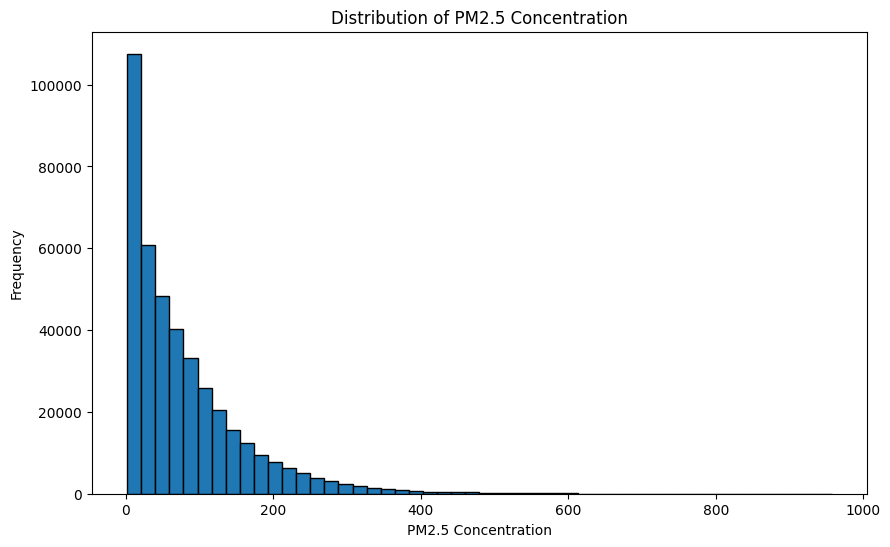

PM2.5 summary statistics:


count    411800.00
mean         79.60
std          80.48
min           2.00
25%          20.00
50%          55.00
75%         111.00
max         957.00
Name: PM2.5, dtype: float64

In [8]:
# Distribution of PM2.5

plt.figure(figsize=(10, 6))
plt.hist(df_clean["PM2.5"], bins=50, edgecolor="black")
plt.xlabel("PM2.5 Concentration")
plt.ylabel("Frequency")
plt.title("Distribution of PM2.5 Concentration")
plt.show()

print("PM2.5 summary statistics:")
display(df_clean["PM2.5"].describe().round(2))

## PM2.5 Distribution

The PM2.5 distribution is strongly right-skewed. Most observations fall within lower PM2.5 concentration ranges, while a smaller number of observations show very high pollution levels. This suggests that extreme pollution events occur less frequently but may have a major impact on the overall distribution. Because PM2.5 is not normally distributed, summary statistics such as the median and percentiles may be useful in addition to the mean.

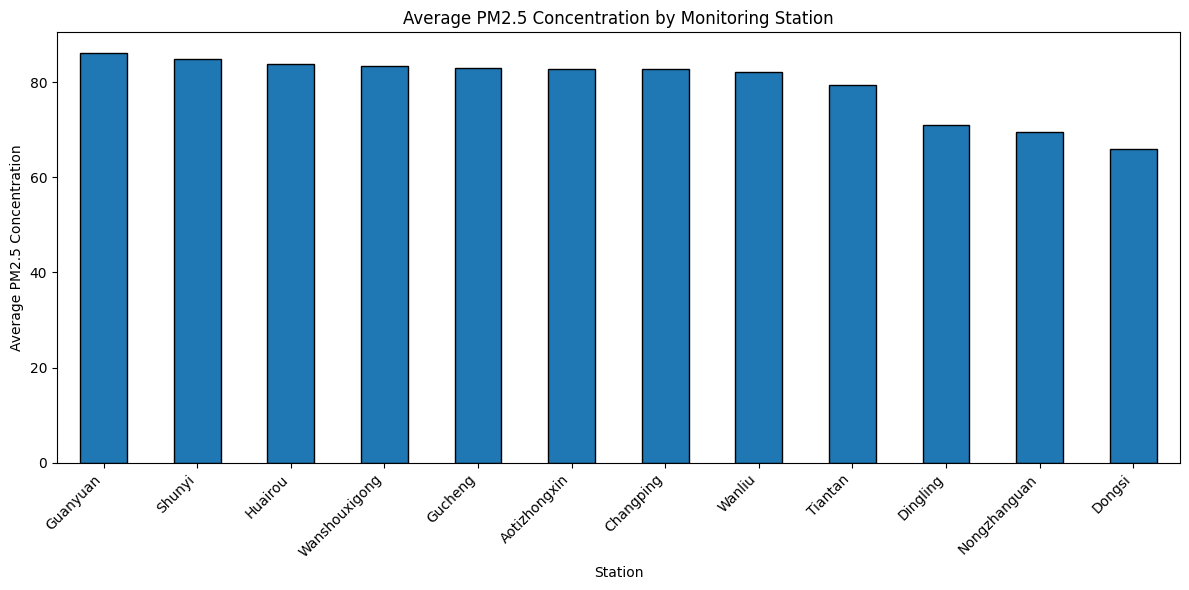

station
Guanyuan         86.19
Shunyi           84.84
Huairou          83.85
Wanshouxigong    83.37
Gucheng          82.93
Aotizhongxin     82.77
Changping        82.77
Wanliu           82.16
Tiantan          79.49
Dingling         71.10
Nongzhanguan     69.63
Dongsi           65.99
Name: PM2.5, dtype: float64

In [9]:
# Average PM2.5 by station

pm25_by_station = (
    df_clean.groupby("station")["PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
pm25_by_station.plot(kind="bar", edgecolor="black")
plt.xlabel("Station")
plt.ylabel("Average PM2.5 Concentration")
plt.title("Average PM2.5 Concentration by Monitoring Station")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

pm25_by_station.round(2)

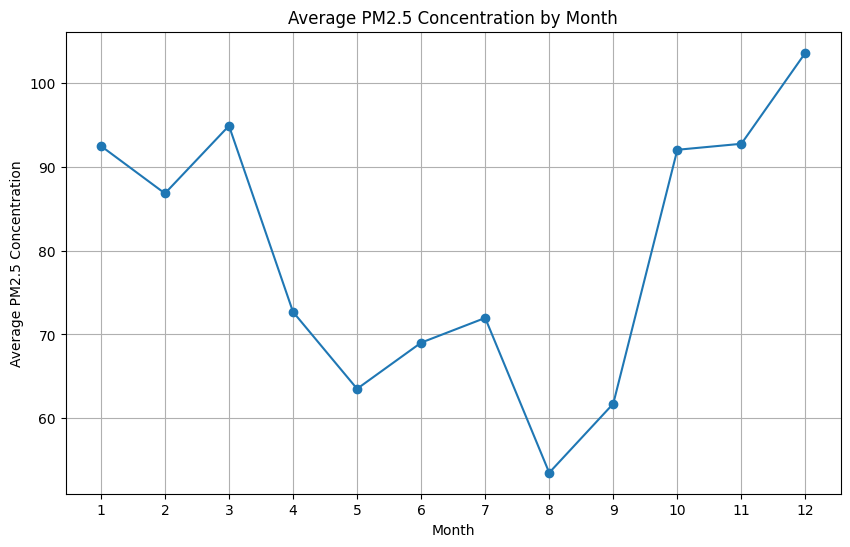

month
1      92.50
2      86.83
3      94.91
4      72.69
5      63.51
6      69.02
7      71.97
8      53.49
9      61.74
10     92.04
11     92.76
12    103.63
Name: PM2.5, dtype: float64

In [10]:
# Average PM2.5 by month

pm25_by_month = (
    df_clean.groupby("month")["PM2.5"]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.plot(pm25_by_month.index, pm25_by_month.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average PM2.5 Concentration")
plt.title("Average PM2.5 Concentration by Month")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

pm25_by_month.round(2)

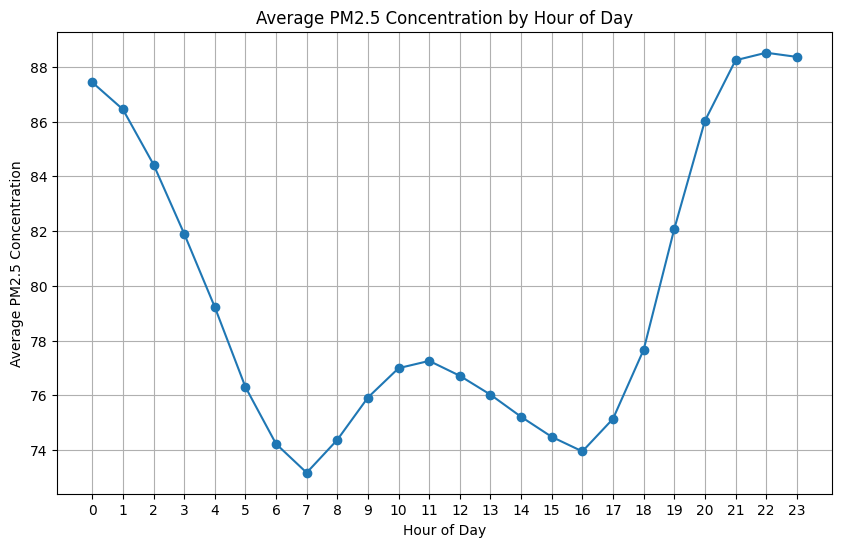

hour
0     87.44
1     86.45
2     84.43
3     81.91
4     79.23
5     76.31
6     74.23
7     73.17
8     74.38
9     75.92
10    76.99
11    77.26
12    76.71
13    76.03
14    75.22
15    74.48
16    73.95
17    75.14
18    77.66
19    82.08
20    86.03
21    88.24
22    88.52
23    88.37
Name: PM2.5, dtype: float64

In [11]:
# Average PM2.5 by hour of day

pm25_by_hour = (
    df_clean.groupby("hour")["PM2.5"]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.plot(pm25_by_hour.index, pm25_by_hour.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average PM2.5 Concentration")
plt.title("Average PM2.5 Concentration by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

pm25_by_hour.round(2)

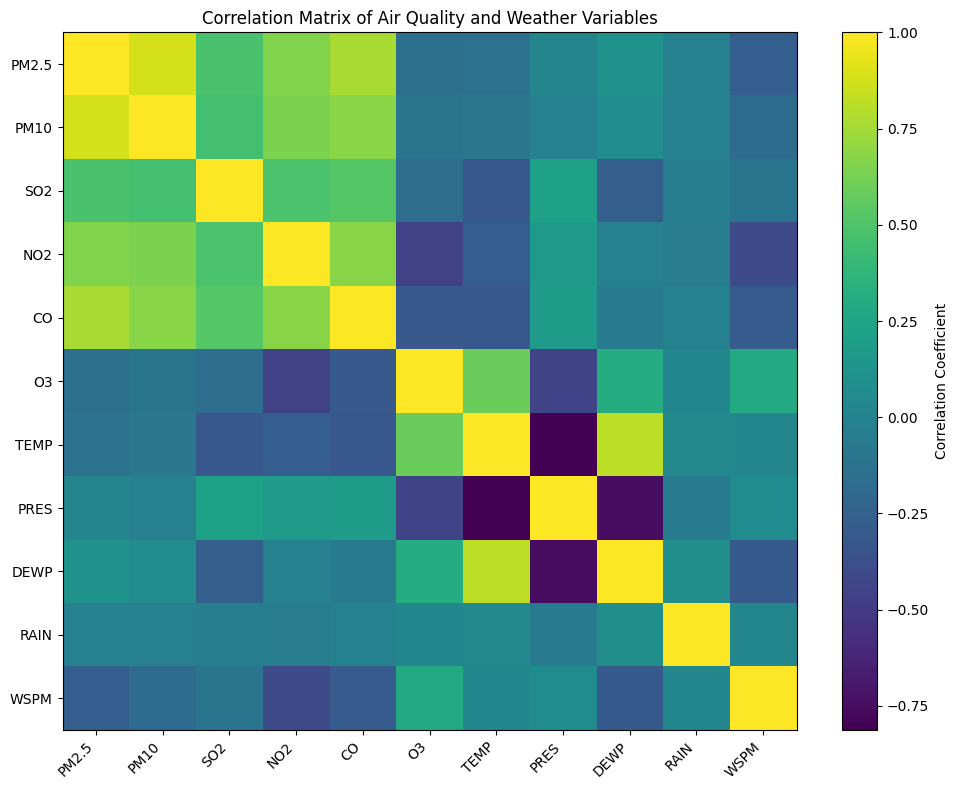

PM2.5    1.00
PM10     0.88
CO       0.77
NO2      0.66
SO2      0.48
DEWP     0.12
PRES     0.02
RAIN    -0.01
TEMP    -0.13
O3      -0.15
WSPM    -0.27
Name: PM2.5, dtype: float64

In [12]:
# Correlation analysis for numeric variables

numeric_columns = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

correlation_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation Coefficient")
plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=45, ha="right")
plt.yticks(range(len(numeric_columns)), numeric_columns)
plt.title("Correlation Matrix of Air Quality and Weather Variables")
plt.tight_layout()
plt.show()

correlation_matrix["PM2.5"].sort_values(ascending=False).round(2)

## Key EDA Findings

The exploratory analysis shows several important patterns in the Beijing Multi-Site Air Quality dataset:

1. The combined dataset includes 420,768 observations from 12 monitoring stations. After removing rows with missing PM2.5 values and imputing other missing values, the cleaned working dataset contains 411,800 observations.

2. PM2.5 concentration is strongly right-skewed. Most observations are relatively low, but some observations show very high pollution levels, suggesting the presence of extreme pollution events.

3. Average PM2.5 levels vary by monitoring station. Guanyuan, Shunyi, and Huairou show some of the highest average PM2.5 values, while Dongsi shows one of the lowest average values.

4. PM2.5 shows a seasonal pattern. Average PM2.5 is higher during colder months, especially December, January, February, and March, and lower during summer months, especially August.

5. PM2.5 also shows an hourly pattern. Concentrations tend to increase during evening and nighttime hours and decrease during parts of the morning and afternoon.

6. Correlation analysis suggests that PM2.5 has strong positive relationships with other pollutant variables such as PM10, CO, NO2, and SO2. These variables may be useful predictors in the modeling stage.